In [1]:
import os
from dotenv import load_dotenv

load_dotenv("/home/abhi/AI_Workspace/personal/Generative-AI-Engineer-Portfolio/.env")

# Azure OpenAI Keys
AZURE_OPENAI_ENDPOINT = os.getenv("AZURE_OPENAI_ENDPOINT")
AZURE_OPENAI_API_KEY = os.getenv("AZURE_OPENAI_API_KEY")
AZURE_OPENAI_LLM_MODEL = os.getenv("AZURE_OPENAI_LLM_MODEL")
AZURE_OPENAI_EMBEDDINGS_MODEL = os.getenv("AZURE_OPENAI_EMBEDDINGS_MODEL")

# Astra DB
ASTRA_DB_APPLICATION_TOKEN = os.getenv("ASTRA_DB_APPLICATION_TOKEN")
ASTRA_DB_API_ENDPOINT = os.getenv("ASTRA_DB_API_ENDPOINT")
ASTRA_DB_COLLECTION = "langchain_pdf_rag"

In [2]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader

urls = [
    "https://lilianweng.github.io/posts/2024-07-07-hallucination/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/"
]

docs = [ WebBaseLoader(url).load() for url in urls ]
docs = [doc for sublist in docs for doc in sublist]  # Flatten the list of lists
docs

2026-02-26 17:20:47.304361: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-26 17:20:47.350255: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-26 17:20:48.362666: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/abhi/.virtualenvs/my_genai_venv/lib/python3.11/site-packages/torch/cuda/__

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2024-07-07-hallucination/', 'title': "Extrinsic Hallucinations in LLMs | Lil'Log", 'description': 'Hallucination in large language models usually refers to the model generating unfaithful, fabricated, inconsistent, or nonsensical content. As a term, hallucination has been somewhat generalized to cases when the model makes mistakes. Here, I would like to narrow down the problem of hallucination to cases where the model output is fabricated and not grounded by either the provided context or world knowledge.\nThere are two types of hallucination:\n\nIn-context hallucination: The model output should be consistent with the source content in context.\nExtrinsic hallucination: The model output should be grounded by the pre-training dataset. However, given the size of the pre-training dataset, it is too expensive to retrieve and identify conflicts per generation. If we consider the pre-training data corpus as a proxy for world k

In [3]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=1000, chunk_overlap=200)
doc_splits = text_splitter.split_documents(docs)
doc_splits[:10]

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2024-07-07-hallucination/', 'title': "Extrinsic Hallucinations in LLMs | Lil'Log", 'description': 'Hallucination in large language models usually refers to the model generating unfaithful, fabricated, inconsistent, or nonsensical content. As a term, hallucination has been somewhat generalized to cases when the model makes mistakes. Here, I would like to narrow down the problem of hallucination to cases where the model output is fabricated and not grounded by either the provided context or world knowledge.\nThere are two types of hallucination:\n\nIn-context hallucination: The model output should be consistent with the source content in context.\nExtrinsic hallucination: The model output should be grounded by the pre-training dataset. However, given the size of the pre-training dataset, it is too expensive to retrieve and identify conflicts per generation. If we consider the pre-training data corpus as a proxy for world k

In [4]:
from langchain_openai import AzureChatOpenAI, AzureOpenAIEmbeddings

embedding_model = AzureOpenAIEmbeddings(
    api_key = AZURE_OPENAI_API_KEY,
    azure_endpoint = AZURE_OPENAI_ENDPOINT,
    model = AZURE_OPENAI_EMBEDDINGS_MODEL,
    api_version = "2024-12-01-preview",
    dimensions = 1024
)
embedding_model

AzureOpenAIEmbeddings(client=<openai.resources.embeddings.Embeddings object at 0x70d63c523d50>, async_client=<openai.resources.embeddings.AsyncEmbeddings object at 0x70d637d48310>, model='text-embedding-3-large', dimensions=1024, deployment=None, openai_api_version='2024-12-01-preview', openai_api_base=None, openai_api_type='azure', openai_proxy=None, embedding_ctx_length=8191, openai_api_key=SecretStr('**********'), openai_organization=None, allowed_special=None, disallowed_special=None, chunk_size=2048, max_retries=2, request_timeout=None, headers=None, tiktoken_enabled=True, tiktoken_model_name=None, show_progress_bar=False, model_kwargs={}, skip_empty=False, default_headers=None, default_query=None, retry_min_seconds=4, retry_max_seconds=20, http_client=None, http_async_client=None, check_embedding_ctx_length=True, azure_endpoint='https://pfs-2-namit-resource.cognitiveservices.azure.com/', azure_ad_token=None, azure_ad_token_provider=None, azure_ad_async_token_provider=None, valida

In [5]:
from langchain_astradb import AstraDBVectorStore
vector_store = AstraDBVectorStore(
    collection_name=ASTRA_DB_COLLECTION,
    embedding=embedding_model,
    api_endpoint=ASTRA_DB_API_ENDPOINT,
    token=ASTRA_DB_APPLICATION_TOKEN
)

vector_store

In [6]:
vector_store.clear() #Delete all old data from the collection
vector_store.add_documents(documents=doc_splits)

['5b1358a7842f41298d9d4fecb3ad4ad4',
 'f1b0b87e0f4a4cffad229adb634d0e36',
 '64b80916fae7499ebef2374af3ca2c3b',
 '9278db89f4104ed7bd0372821bd37d14',
 '2b68fae2bf02417c85fac007a1cef4a4',
 '96ec2f7701544008ac96df06db2dfc1f',
 'ece4a2fb76dd4a0ab510385fcc10dd19',
 '28584a74926a4d098ceb6eea9c9d9cd2',
 '60df46f5fe1e465bac488db6ee858da6',
 '77185cf72c1744de9dc709b9cc3eaa0a',
 'e39b8c26b6644634be82116efbb235ea',
 'b3fa4aa257d5420686c33c1228123e22',
 'b4380c8b4eed4c579cb1180324858ce0',
 '0897c29cca5c487795954062efaa1958',
 'ce1b918f07e245ad8653385ec76e23d4',
 '94bcd932211b4d56988921167ed495b5',
 '1fbb76a21b034b2bbd7ddc085ebb675b',
 '492197adfdf8463f896f0dff95046a4b',
 '9c122ac7d37d4dd5a57b851bcbecba31',
 '92d82fc9feb342738658d016ba9a514d',
 '1c64f34686c942228755398ad5189a24',
 '623c10e2d665496da28c5d58d6cb814a',
 '394c6ddeafc6461d8a8a664e56890afd',
 'f281f0a7df574a7c805aeeeea8057017',
 'ebc3eb4507274cc4b15c0ac722662717',
 'bf1817b60b404c54bf07e0a32fc8dcfc',
 '5700975dadf648ce8602783006452ada',
 

In [7]:
#Create retriever from vector store
retriever = vector_store.as_retriever(kwargs={"k":5})
retriever

VectorStoreRetriever(tags=['AstraDBVectorStore', 'AzureOpenAIEmbeddings'], vectorstore=<langchain_astradb.vectorstores.AstraDBVectorStore object at 0x70d637d4ac10>, search_kwargs={})

In [8]:
retriever.invoke("What is an agent?")

[Document(id='5c64e709bd6c4ad6b32cc6b477208575', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, ther

In [9]:
from typing import Literal

from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser

In [10]:
class RouteQuery(BaseModel):
    """Routes a user query to the most relevant datasource."""
    datasource: Literal["vectorstore", "wiki_search"] = Field(
        ...,
        description="The datasource to route the query to. Can be either 'vectorstore' or 'wiki_search'."
    )

parser = PydanticOutputParser(pydantic_object=RouteQuery)

In [11]:
llm = AzureChatOpenAI(
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    azure_deployment=AZURE_OPENAI_LLM_MODEL,
    api_version="2025-04-01-preview",
    api_key=AZURE_OPENAI_API_KEY,
    max_tokens=4096,
)
llm

AzureChatOpenAI(profile={}, client=<openai.resources.chat.completions.completions.Completions object at 0x70d6375613d0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x70d637562190>, root_client=<openai.lib.azure.AzureOpenAI object at 0x70d6375b05d0>, root_async_client=<openai.lib.azure.AsyncAzureOpenAI object at 0x70d6375615d0>, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True, max_tokens=4096, disabled_params={'parallel_tool_calls': None}, azure_endpoint='https://pfs-2-namit-resource.cognitiveservices.azure.com/', deployment_name='gpt-5.2-chat', openai_api_version='2025-04-01-preview', openai_api_type='azure')

In [13]:
structured_llm_router = llm.with_structured_output(schema=RouteQuery)
structured_llm_router

RunnableBinding(bound=AzureChatOpenAI(profile={}, client=<openai.resources.chat.completions.completions.Completions object at 0x70d6375613d0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x70d637562190>, root_client=<openai.lib.azure.AzureOpenAI object at 0x70d6375b05d0>, root_async_client=<openai.lib.azure.AsyncAzureOpenAI object at 0x70d6375615d0>, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True, max_tokens=4096, disabled_params={'parallel_tool_calls': None}, azure_endpoint='https://pfs-2-namit-resource.cognitiveservices.azure.com/', deployment_name='gpt-5.2-chat', openai_api_version='2025-04-01-preview', openai_api_type='azure'), kwargs={'response_format': <class '__main__.RouteQuery'>, 'ls_structured_output_format': {'kwargs': {'method': 'json_schema', 'strict': None}, 'schema': {'type': 'function', 'function': {'name': 'RouteQuery', 'description': 'Routes a user query to the most relevant datasource.', 'paramete

In [14]:
system_prompt = """You are an expert to routing a user question to a vectorstore or wikipedia.
The vectorstore contains information about agents, hallucinations and adversarial attacks in LLMs. Use the vectorstore if the question is related to these topics. Use wikipedia for all other questions.
"""
route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt), 
        ("human", "Question: {question}"),
    ]
)

question_router = route_prompt | structured_llm_router

In [15]:
print(question_router.invoke({"question": "What is an agent?"}))

datasource='vectorstore'


/home/abhi/.virtualenvs/my_genai_venv/lib/python3.11/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=RouteQuery(datasource='vectorstore'), input_type=RouteQuery])
  return self.__pydantic_serializer__.to_python(


In [16]:
print(question_router.invoke({"question": "Who is Shahrukh Khan?"}))

datasource='wiki_search'


/home/abhi/.virtualenvs/my_genai_venv/lib/python3.11/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=RouteQuery(datasource='wiki_search'), input_type=RouteQuery])
  return self.__pydantic_serializer__.to_python(


In [19]:
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import WikipediaQueryRun
# 1. Create API wrappers for the tools
wiki_wrapper = WikipediaAPIWrapper(
    top_k_results=1,
    doc_content_chars_max=500
)
wiki_tool = WikipediaQueryRun(
    api_wrapper=wiki_wrapper,
    description="Search Wikipedia for general knowledge answers"
)

In [20]:
#AIAgent app using LangGraph
from typing import List
from typing_extensions import TypedDict

class GraphState(TypedDict):
    """
    Represents the state of our graph
    Attributes:
        question: The user's question
        generation: The answer generated by the LLM
        documents: list of documents
    """
    question: str
    generation: str
    documents: List[str]

In [24]:
def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updated graph state with retrieved documents
    """
    print("----Retrieve----")
    question=state["question"]

    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}

In [25]:
from langchain_core.documents import Document
def wiki_search(state):
    """
    Wikipedia search based on the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updated graph state with appended documents from Wikipedia search
    """
    print("----Wikipedia----")
    question=state["question"]

    docs = wiki_tool.invoke(question)
    documents = Document(page_content=docs)
    return {"documents": documents, "question": question}

In [27]:
def route_question(state):
    """
    Routes the question to either vectorstore retrieval or wikipedia search based on the question.

    Args:
        state (dict): The current graph state  
    
    Returns:
        str: Next node to call
    """
    print("----Route Question----")
    question = state["question"]
    source = question_router.invoke({"question": question})
    if source.datasource == "wiki_search":
        return "wiki_search"
    elif source.datasource == "vectorstore":
        print("----ROUTE QUESTION TO RAG----")
        return "vectorstore"

In [34]:
from langgraph.graph import START, END, StateGraph

workflow = StateGraph(GraphState)

workflow.add_node("wiki_search", wiki_search)
workflow.add_node("retrieve", retrieve)

workflow.add_conditional_edges(
    START,
    route_question,
    {
        "wiki_search": "wiki_search",
        "vectorstore": "retrieve"
    },
)

workflow.add_edge("retrieve", END)
workflow.add_edge("wiki_search", END)

app = workflow.compile()

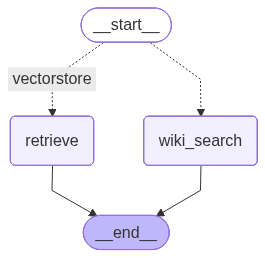

In [35]:
from IPython.display import Image, display
try:
  display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
  pass

In [38]:
while True:
  user_input = input("User (Enter any input or type 'quit' / q to exit): ")
  if user_input.lower().strip() in ["quit", "q"]:
    print("Good Bye!")
    break
  print(f"\nQuestion: {user_input}\n")
  for event in app.stream({"question": user_input}):
    for key, value in event.items():
      if isinstance(value, dict) and "documents" in value:
        docs = value["documents"]
        print("\n--- Retrieved Documents ---")
        if isinstance(docs, list):
          for doc in docs:
            print(f"Source: {doc.metadata.get('source', 'Unknown')}")
            print(f"Content: {doc.page_content[:300]}...\n")
        else:
          print(f"Content: {docs.page_content[:300]}...\n")


Question: Who is SRK?

----Route Question----
----Wikipedia----

--- Retrieved Documents ---
Content: Page: Shah Rukh Khan
Summary: Shah Rukh Khan (pronounced [ˈʃaːɦɾʊx xäːn] ; born as Shahrukh Khan on 2 November 1965), popularly known by the initials SRK, is an Indian actor and film producer renowned for his work in Hindi cinema. Referred to in the media as the "Baadshah of Bollywood" and "King Kha...

Good Bye!
